# Optimisation Investigation

This is a notebook to investigate and improve the optimisation procedure for interval boundaries, guard bands, etc; as used in `key_efficiency_comparison_for_paper.ipynb`. Essentially, before this investigation, the \tau recovered is jagged and not smooth. Even though, it should be smooth. This is due to some sort of artifact from the optimisation procedure. To be fair, the min() etc ensure that the function is not smooth or convex, so the optimisation is challenging.

Things to investigate:
- Initial sanity checks
  - First, perform DW optimisation like in `key_efficiency_comparison_for_paper.ipynb', as a sanity check.
  - Then, perform SR optimisation with $m=1$. This involves only optimising $V_\text{mod}$, and currently works nicely in `key_efficiency_comparison_for_paper.ipynb'. 
- SR $m=2$ test case.
    - This is the first non-trivial case. This involves optimising $V_\text{mod}$ and the single boundary $\tau_3$. ($\tau_0 = -\infty, \tau_1-\tau_3, \tau_2 = 0, \tau_4 = +\infty$).


In [13]:
# imports etc
import numpy as np
from scipy.stats import norm
from scipy.optimize import minimize, minimize_scalar
from scipy import integrate
import matplotlib.pyplot as plt

import importlib

SR = importlib.import_module('guard_band_postselection.SR').SR
GBSR = importlib.import_module('guard_band_postselection.GBSR').GBSR
MD = importlib.import_module('guard_band_postselection.MD').MD

LDPCSimpleModel = importlib.import_module('guard_band_postselection.code_efficiency').LDPCSimpleModel
make_eta_c_provider = importlib.import_module('guard_band_postselection.code_efficiency').make_eta_c_provider


## Parameters

In [14]:
# Parameters
v_mod_bounds = (0.001, 30.0)
excess_noise = 0.001
Delta_QCT = 0.0
eta_c = 0.97  # coding efficiency (constant for now)
distances_km = np.logspace(-2, 2, num=100)

def fibre_transmittance(distance_km, loss_db_per_km=0.2):
    """Return the channel transmittance for a fibre segment of length `distance_km`."""
    return 10 ** (-loss_db_per_km * distance_km / 10)


## Notebook Method Overrides and Utilities

In [15]:
# Put method overrides here, that override methods in SR.py etc.

import math

class SRNotebook(SR):
    """Notebook-local subclass to enforce LSB (binary) mapping and
    provide (v, u) helpers for m=2 experiments without touching SR.py.
    
    v = log(V_mod),
    u = tau_3 / sqrt(V_mod), with symmetric edges: [-inf, -u, 0, u, inf].
    """

    def evaluate_reconciliation_efficiency(self, tau_arr, g_arr=None, *, code_efficiency=None, bit_assignment="binary"):
        # Force binary (LSB) mapping by default for reproducibility here.
        return super().evaluate_reconciliation_efficiency(
            tau_arr, g_arr, code_efficiency=code_efficiency, bit_assignment="binary"
        )

    # Convenience helpers for m=2
    @staticmethod
    def tau_from_u(u: float):
        """Return normalised edges for m=2 given u = tau_3 / sqrt(V_mod).
        Edges are [-inf, -u, 0, u, inf].
        """
        return [-math.inf, -float(u), 0.0, float(u), math.inf]

    def key_rate_for_u(self, u: float, *, code_efficiency=None) -> float:
        tau = self.tau_from_u(u)
        return float(self.evaluate_key_rate_in_bits_per_pulse(tau, code_efficiency=code_efficiency, bit_assignment="binary"))

# Helper functions to scan u and v for m=2
def scan_K_vs_u(V_mod: float, T: float, xi: float, *, u_min=0.2, u_max=2.5, num=400, eta_c=0.97):
    sr = SRNotebook(m=2, modulation_variance=float(V_mod), transmittance=float(T), excess_noise=float(xi), code_efficiency=eta_c)
    grid = np.linspace(float(u_min), float(u_max), int(num))
    K = np.array([sr.key_rate_for_u(u) for u in grid], dtype=float)
    return grid, K

def scan_K_vs_v(u: float, T: float, xi: float, *, v_min=None, v_max=None, num=400, eta_c=0.97):
    # Default v-range from bounds used elsewhere if not provided
    if v_min is None:
        v_min = math.log(v_mod_bounds[0])
    if v_max is None:
        v_max = math.log(v_mod_bounds[1])
    v_grid = np.linspace(float(v_min), float(v_max), int(num))
    K = []
    for v in v_grid:
        V_mod = float(math.exp(v))
        sr = SRNotebook(m=2, modulation_variance=V_mod, transmittance=float(T), excess_noise=float(xi), code_efficiency=eta_c)
        tau = SRNotebook.tau_from_u(u)
        K.append(sr.evaluate_key_rate_in_bits_per_pulse(tau, bit_assignment="binary"))
    return v_grid, np.array(K, dtype=float)


In [16]:
def scan_K_vs_u_analytic(V_mod: float, T: float, xi: float, *, u_min=0.2, u_max=2.5, num=400, eta_c=0.97, quadrature_points: int = 240, integrand: str = 'hard', beta: float = None, fold: str = 'hard', fold_beta: float = 20.0, integration_method: str = 'gh', quad_opts: dict | None = None):
    sr = SRAnalytic(m=2, modulation_variance=float(V_mod), transmittance=float(T), excess_noise=float(xi), code_efficiency=eta_c)
    grid = np.linspace(float(u_min), float(u_max), int(num))
    K = np.array([sr.evaluate_key_rate_for_u(u, quadrature_points=quadrature_points, integrand=integrand, beta=beta, fold=fold, fold_beta=fold_beta, integration_method=integration_method, quad_opts=quad_opts) for u in grid], dtype=float)
    return grid, K


def scan_K_vs_v_analytic(u: float, T: float, xi: float, *, v_min=None, v_max=None, num=400, eta_c=0.97, quadrature_points: int = 240, integrand: str = 'hard', beta: float = None, fold: str = 'hard', fold_beta: float = 20.0, integration_method: str = 'gh', quad_opts: dict | None = None):
    if v_min is None:
        v_min = math.log(v_mod_bounds[0])
    if v_max is None:
        v_max = math.log(v_mod_bounds[1])
    v_grid = np.linspace(float(v_min), float(v_max), int(num))
    K = []
    for v in v_grid:
        V_mod = float(math.exp(v))
        sr = SRAnalytic(m=2, modulation_variance=V_mod, transmittance=float(T), excess_noise=float(xi), code_efficiency=eta_c)
        K.append(sr.evaluate_key_rate_for_u(u, quadrature_points=quadrature_points, integrand=integrand, beta=beta, fold=fold, fold_beta=fold_beta, integration_method=integration_method, quad_opts=quad_opts))
    return v_grid, np.array(K, dtype=float)


TypeError: unsupported operand type(s) for |: 'type' and 'NoneType'

In [ ]:
# Monkey-patch SRAnalytic to override SR-style API using analytic slice errors (m=2 only)
# Provides smooth/soft options and keeps compatibility with evaluate_reconciliation_efficiency

import numpy as np

def _is_symmetric_tau_m2(tau_arr):
    # tau_arr expected normalized: [-inf, -u, 0, u, inf]
    if len(tau_arr) != 5:
        return False
    a,b,c,d,e = tau_arr
    return (np.isneginf(a) and np.isposinf(e) and np.isclose(c, 0.0) and np.isclose(-b, d))


def _reconcile_analytic(self, tau_arr, g_arr=None, *, code_efficiency=None, bit_assignment="binary", quadrature_points: int = 256, integrand: str = 'soft', beta: float = 20.0, fold: str = 'soft', fold_beta: float = 20.0, integration_method: str = 'gh', quad_opts: dict | None = None):
    # If not m=2 symmetric tau, fall back to SR
    if getattr(self, 'm', None) != 2 or not _is_symmetric_tau_m2(tau_arr):
        return super(SRAnalytic, self).evaluate_reconciliation_efficiency(tau_arr, g_arr, code_efficiency=code_efficiency, bit_assignment='binary')

    # Compute quantization entropy as in SR
    H_Q = float(self.evaluate_quantisation_entropy(tau_arr))

    # Derive u from tau
    u = float(tau_arr[3])

    # Raw slice errors via analytic posterior-only method
    raw_errors = self.slice_errors_m2(u, quadrature_points=quadrature_points, integrand=integrand, beta=beta if integrand=='soft' else None, integration_method=integration_method, quad_opts=quad_opts)
    # Clamp raw errors to [0,1] to avoid FP spillover
    raw_errors = np.clip(raw_errors, 0.0, 1.0)

    # Smooth fold for capacity
    if fold == 'hard':
        e_eff = np.minimum(raw_errors, 1.0 - raw_errors)
    elif fold == 'soft':
        e_eff = self._softmin(raw_errors, 1.0 - raw_errors, float(fold_beta))
    else:
        raise ValueError('fold must be "hard" or "soft"')

    # Capacity per slice: 1 - h2(e_eff)
    # Ensure e_eff within (0,1) for entropy stability
    e_eff = np.clip(e_eff, 1e-12, 1 - 1e-12)
    h2 = np.array([self._binary_entropy(float(e)) for e in e_eff], dtype=float)
    capacities = 1.0 - h2

    # Code efficiency vector
    try:
        coding_efficiencies = self._evaluate_code_efficiency(e_eff, override=code_efficiency)
    except Exception:
        if code_efficiency is None:
            coding_efficiencies = self._evaluate_code_efficiency(e_eff)
        else:
            coding_efficiencies = float(code_efficiency) * np.ones_like(capacities)

    code_rates = np.asarray(coding_efficiencies * capacities, dtype=float)
    leak_terms = 1.0 - code_rates  # no clip to avoid kinks

    bits_sent = H_Q
    bits_leaked = float(leak_terms.sum())
    numerator = bits_sent - bits_leaked
    denominator = max(self.I_AB, 1e-12)
    eta = numerator / denominator if denominator > 0.0 else 0.0
    key_rate = numerator - self._holevo_with_qct()

    slice_metrics = []
    for raw, eff, cap, eta_c, rate, leak in zip(raw_errors, e_eff, capacities, coding_efficiencies, code_rates, leak_terms):
        slice_metrics.append({
            "raw_error_rate": float(raw),
            "error_rate": float(eff),
            "capacity": float(cap),
            "coding_efficiency": float(eta_c),
            "code_rate": float(rate),
            "leak": float(leak),
        })

    return {
        "eta": float(eta),
        "bits_sent": float(bits_sent),
        "bits_leaked": float(bits_leaked),
        "key_rate": float(key_rate),
        "quantisation_entropy": float(H_Q),
        "slices": slice_metrics,
        "I_AB": self.I_AB,
        "holevo": float(self._holevo_with_qct()),
    }


def _key_rate_api(self, tau_arr, g_arr=None, *, code_efficiency=None, bit_assignment="binary", **kwargs):
    metrics = self.evaluate_reconciliation_efficiency(tau_arr, g_arr, code_efficiency=code_efficiency, bit_assignment=bit_assignment, **kwargs)
    return metrics["key_rate"]


def _slice_errors_m2_cached(self, u: float, *, quadrature_points: int = 240, integrand: str = 'hard', beta: float | None = None, integration_method: str = 'gh', quad_opts: dict | None = None) -> np.ndarray:
    method = integration_method.lower()
    if method == 'quad':
        return self._slice_errors_m2_quad(u, integrand=integrand, beta=beta, quad_opts=quad_opts)
    if method != 'gh':
        raise ValueError("integration_method must be 'gh' or 'quad'")
    nodes, weights = _cached_hermgauss_nodes(int(quadrature_points))
    return self._slice_errors_m2_gausshermite(u, nodes, weights, integrand=integrand, beta=beta)

# Bind the overrides onto the class
SRAnalytic.evaluate_reconciliation_efficiency = _reconcile_analytic
SRAnalytic.evaluate_key_rate_in_bits_per_pulse = _key_rate_api
SRAnalytic.slice_errors_m2 = _slice_errors_m2_cached

In [ ]:
# Path A utilities: beta annealing (5?10?20?40), coordinate descent, hard evaluation at soft optimum
from functools import lru_cache
from dataclasses import dataclass
from typing import Optional

V_LOG_BOUNDS = (float(np.log(v_mod_bounds[0])), float(np.log(v_mod_bounds[1])))
U_BOUNDS = (0.2, 2.5)
GH_MAX = 256
_DEFAULT_BETA_SCHEDULE = (5.0, 10.0, 20.0, 40.0)

@lru_cache(maxsize=None)
def _cached_hermgauss_nodes(order: int):
    if order > GH_MAX:
        raise ValueError(f"Gauss-Hermite order {order} exceeds maximum allowed {GH_MAX}")
    return np.polynomial.hermite.hermgauss(order)

@dataclass
class SoftStageResult:
    beta: float
    v_opt: float
    u_opt: float
    K_soft: float
    metrics_soft: dict
    n_eval: int
    iterations: int

@dataclass
class PathASummary:
    distance_km: float
    stages: list
    v_opt: float
    u_opt: float
    V_mod_opt: float
    tau_opt: float
    K_hard: float
    metrics_hard: dict
    warm_start: tuple[float, float]

def evaluate_key_rate_pathA(v: float, u: float, *, distance_km: float, beta: float = None, integrand: str = 'hard', fold: str = 'hard', fold_beta: float = None, quadrature_points: int = 256, integration_method: str = 'gh', quad_opts: dict | None = None) -> tuple[float, dict]:
    if integrand == 'soft' and beta is None:
        raise ValueError('beta must be specified for soft integrand')
    method = integration_method.lower()
    if method == 'gh' and quadrature_points > GH_MAX:
        raise ValueError(f'quadrature_points {quadrature_points} exceeds GH maximum {GH_MAX}')
    V_mod = float(np.exp(v))
    sr = SRAnalytic(
        m=2,
        modulation_variance=V_mod,
        transmittance=float(fibre_transmittance(distance_km)),
        excess_noise=float(excess_noise),
        Delta_QCT=Delta_QCT,
        code_efficiency=eta_c,
    )
    tau = sr.tau_from_u(u)
    kwargs = dict(quadrature_points=quadrature_points, integrand=integrand, fold=fold, integration_method=integration_method)
    if integrand == 'soft':
        kwargs['beta'] = beta
    if fold == 'soft':
        kwargs['fold_beta'] = fold_beta if fold_beta is not None else beta
    if quad_opts is not None:
        kwargs['quad_opts'] = quad_opts
    K = sr.evaluate_key_rate_in_bits_per_pulse(tau, **kwargs)
    metrics = dict(sr.evaluate_reconciliation_efficiency(tau, **kwargs))
    metrics['V_mod'] = V_mod
    metrics['tau_u'] = float(u)
    metrics['holevo'] = sr._holevo_with_qct()
    return float(K), metrics

def _coordinate_descent_soft(distance_km: float, beta: float, initial_guess: tuple[float, float], *, quadrature_points: int = 256, max_iterations: int = 12, tol: float = 1e-6, v_log_fixed: Optional[float] = None, integration_method: str = 'gh', quad_opts: dict | None = None) -> SoftStageResult:
    v_low, v_high = V_LOG_BOUNDS
    u_low, u_high = U_BOUNDS
    if v_log_fixed is None:
        v = float(np.clip(initial_guess[0], v_low, v_high))
        v_fixed = None
    else:
        v_fixed = float(np.clip(v_log_fixed, v_low, v_high))
        v = v_fixed
    u = float(np.clip(initial_guess[1], u_low, u_high))
    n_eval = 0

    for iteration in range(max_iterations):
        v_prev, u_prev = v, u

        def negK_u(u_candidate):
            if not u_low <= u_candidate <= u_high:
                return np.inf
            nonlocal n_eval
            K, _ = evaluate_key_rate_pathA(v, u_candidate, distance_km=distance_km, beta=beta, integrand='soft', fold='hard', quadrature_points=quadrature_points, integration_method=integration_method, quad_opts=quad_opts)
            n_eval += 1
            return -K

        res_u = minimize_scalar(negK_u, bounds=(u_low, u_high), method='bounded', options={'xatol': 1e-5, 'maxiter': 120})
        u = float(np.clip(res_u.x, u_low, u_high))

        if v_fixed is None:
            def negK_v(v_candidate):
                if not v_low <= v_candidate <= v_high:
                    return np.inf
                nonlocal n_eval
                K, _ = evaluate_key_rate_pathA(v_candidate, u, distance_km=distance_km, beta=beta, integrand='soft', fold='hard', quadrature_points=quadrature_points, integration_method=integration_method, quad_opts=quad_opts)
                n_eval += 1
                return -K

            res_v = minimize_scalar(negK_v, bounds=(v_low, v_high), method='bounded', options={'xatol': 1e-5, 'maxiter': 120})
            v = float(np.clip(res_v.x, v_low, v_high))
        else:
            v = v_fixed

        delta_v = abs(v - v_prev)
        delta_u = abs(u - u_prev)
        if max(delta_v, delta_u) < tol:
            break

    K_soft, metrics_soft = evaluate_key_rate_pathA(v, u, distance_km=distance_km, beta=beta, integrand='soft', fold='hard', quadrature_points=quadrature_points, integration_method=integration_method, quad_opts=quad_opts)
    n_eval += 1
    return SoftStageResult(beta=float(beta), v_opt=float(v), u_opt=float(u), K_soft=K_soft, metrics_soft=metrics_soft, n_eval=n_eval, iterations=iteration + 1)

def _guard_multistart(distance_km: float, beta: float, guess: tuple[float, float], quadrature_points: int, v_log_fixed: Optional[float] = None, *, integration_method: str = 'gh', quad_opts: dict | None = None) -> tuple[float, float]:
    v_center, u_center = guess
    delta_v = 0.10
    delta_u = 0.05
    v_low, v_high = V_LOG_BOUNDS
    u_low, u_high = U_BOUNDS
    if v_log_fixed is None:
        v_candidates = np.clip(v_center + np.array([-delta_v, 0.0, delta_v]), v_low, v_high)
    else:
        v_fixed = float(np.clip(v_log_fixed, v_low, v_high))
        v_candidates = np.array([v_fixed])
        v_center = v_fixed
    u_candidates = np.clip(u_center + np.array([-delta_u, 0.0, delta_u]), u_low, u_high)
    best_v, best_u = float(v_center), float(u_center)
    best_K = -np.inf
    for v in np.unique(v_candidates):
        for u in np.unique(u_candidates):
            K, _ = evaluate_key_rate_pathA(float(v), float(u), distance_km=distance_km, beta=beta, integrand='soft', fold='hard', quadrature_points=quadrature_points, integration_method=integration_method, quad_opts=quad_opts)
            if K > best_K:
                best_K = K
                best_v, best_u = float(v), float(u)
    return best_v, best_u

def run_pathA_single(distance_km: float, *, beta_schedule: tuple[float, ...] = _DEFAULT_BETA_SCHEDULE, quadrature_points: int = 256, initial_guess: tuple[float, float] = None, V_mod_fixed: Optional[float] = None, integration_method: str = 'gh', quad_opts: dict | None = None) -> PathASummary:
    beta_schedule = tuple(beta_schedule)
    v_log_fixed = None if V_mod_fixed is None else float(np.log(V_mod_fixed))
    if initial_guess is None:
        guess = (v_log_fixed if v_log_fixed is not None else float(np.log(4.0)), 0.8)
    else:
        guess_v, guess_u = float(initial_guess[0]), float(initial_guess[1])
        if v_log_fixed is not None:
            guess_v = v_log_fixed
        guess = (guess_v, guess_u)
    stages = []

    first_beta = beta_schedule[0]
    guess = _guard_multistart(distance_km, first_beta, guess, quadrature_points, v_log_fixed=v_log_fixed, integration_method=integration_method, quad_opts=quad_opts)

    for beta in beta_schedule:
        stage = _coordinate_descent_soft(distance_km, beta, guess, quadrature_points=quadrature_points, v_log_fixed=v_log_fixed, integration_method=integration_method, quad_opts=quad_opts)
        stages.append(stage)
        guess = (stage.v_opt, stage.u_opt)

    final_stage = stages[-1]
    V_mod_opt = float(np.exp(final_stage.v_opt))
    tau_opt = float(final_stage.u_opt * math.sqrt(V_mod_opt))
    K_hard, metrics_hard = evaluate_key_rate_pathA(final_stage.v_opt, final_stage.u_opt, distance_km=distance_km, integrand='hard', fold='hard', quadrature_points=quadrature_points, integration_method=integration_method, quad_opts=quad_opts)

    return PathASummary(
        distance_km=float(distance_km),
        stages=stages,
        v_opt=float(final_stage.v_opt),
        u_opt=float(final_stage.u_opt),
        V_mod_opt=V_mod_opt,
        tau_opt=tau_opt,
        K_hard=K_hard,
        metrics_hard=metrics_hard,
        warm_start=(float(final_stage.v_opt), float(final_stage.u_opt)),
    )


## Initial Sanity Checks

- DW
- SR $m=1$

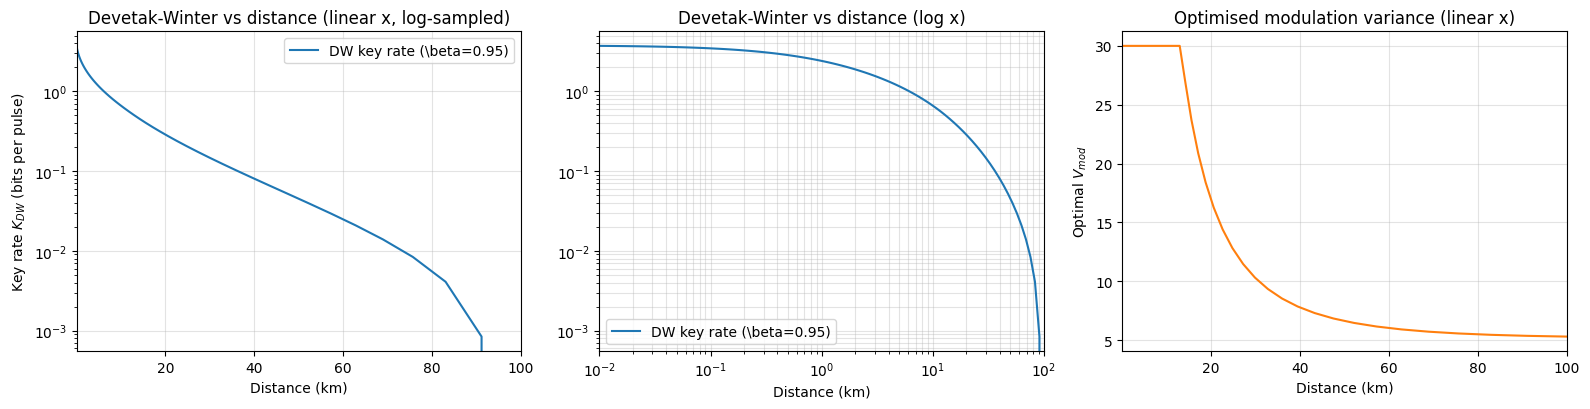

In [17]:
beta_dw = 0.97
optimal_vmods_DW = []
dw_key_rates = []
mutual_infos = []
holevo_terms = []

for distance_km in distances_km:
    T = fibre_transmittance(distance_km)

    def neg_dw_key_rate(v_mod):
        sr_instance = SR(
            m=1,
            modulation_variance=float(v_mod),
            transmittance=float(T),
            excess_noise=excess_noise,
            Delta_QCT=Delta_QCT,
            code_efficiency=eta_c,
        )
        return -sr_instance.evaluate_devetak_winter(beta=beta_dw)

    result = minimize_scalar(neg_dw_key_rate, bounds=v_mod_bounds, method="bounded")
    if not result.success:
        raise RuntimeError(f'V_mod optimisation failed at distance {distance_km} km: {result.message}')
    v_opt = float(result.x)
    optimal_vmods_DW.append(v_opt)

    sr_opt = SR(
        m=1,
        modulation_variance=v_opt,
        transmittance=float(T),
        excess_noise=excess_noise,
        Delta_QCT=Delta_QCT,
        code_efficiency=eta_c,
    )
    dw_rate = sr_opt.evaluate_devetak_winter(beta=beta_dw)
    dw_key_rates.append(dw_rate)
    mutual_infos.append(sr_opt.I_AB)
    holevo_terms.append(sr_opt._holevo_with_qct())

# --- plotting: key rate (linear x), key rate (log x), V_mod (linear x) ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
ax_k_lin, ax_k_log, ax_vmod = axes

# Key rate linear x (points are log-sampled)
ax_k_lin.plot(distances_km, dw_key_rates, label='DW key rate (\\beta=0.95)')
ax_k_lin.set_xlabel('Distance (km)')
ax_k_lin.set_ylabel('Key rate $K_{DW}$ (bits per pulse)')
ax_k_lin.set_title('Devetak-Winter vs distance (linear x, log-sampled)')
ax_k_lin.set_yscale('log')
ax_k_lin.set_xlim(1e-2, 1e2)
ax_k_lin.grid(True, alpha=0.35)
ax_k_lin.legend()

# Key rate log x
ax_k_log.plot(distances_km, dw_key_rates, label='DW key rate (\\beta=0.95)')
ax_k_log.set_xlabel('Distance (km)')
ax_k_log.set_title('Devetak-Winter vs distance (log x)')
ax_k_log.set_yscale('log')
ax_k_log.set_xscale('log')
ax_k_log.set_xlim(1e-2, 1e2)
ax_k_log.grid(True, which='both', alpha=0.35)
ax_k_log.legend()

# V_mod linear x
ax_vmod.plot(distances_km, optimal_vmods_DW, color='tab:orange')
ax_vmod.set_xlabel('Distance (km)')
ax_vmod.set_ylabel('Optimal $V_{mod}$')
ax_vmod.set_title('Optimised modulation variance (linear x)')
ax_vmod.set_xlim(1e-2, 1e2)
ax_vmod.grid(True, alpha=0.35)

fig.tight_layout()

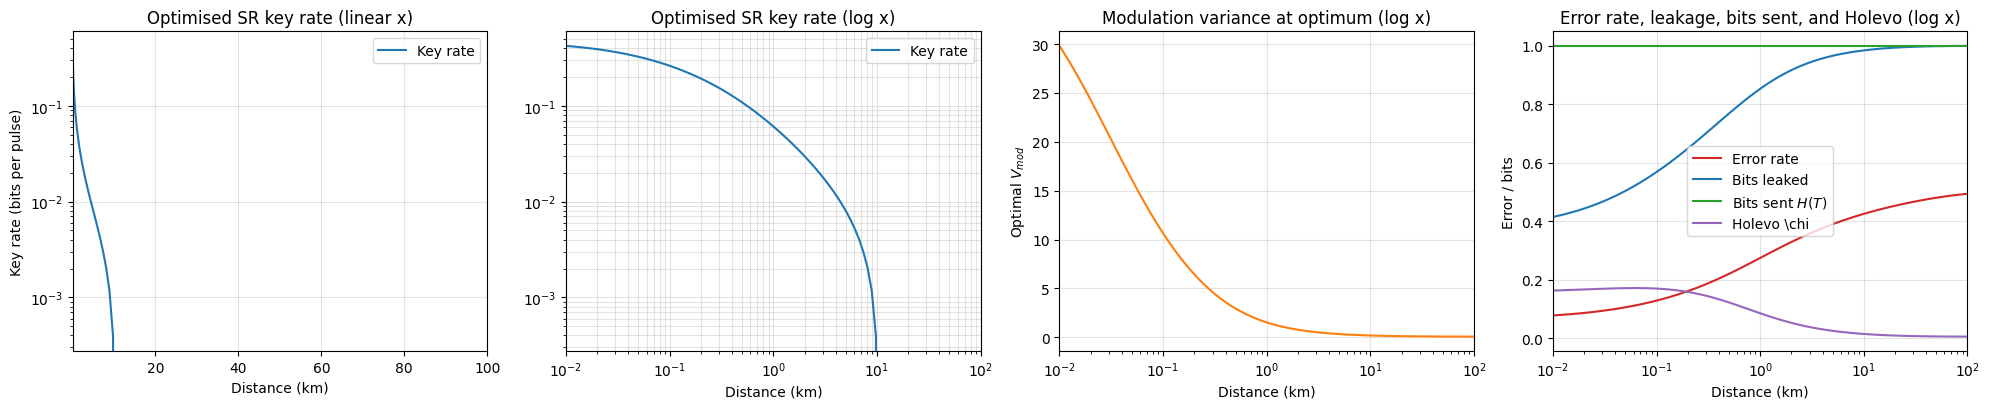

In [18]:
# SR m = 1
tau_sr_m1 = [-np.inf, 0.0, np.inf]

optimal_vmods_DW = []
optimal_key_rates = []
optimal_etas = []
optimal_error_rates = []
optimal_bits_leaked = []
optimal_bits_sent = []
optimal_holevo = []

for distance_km in distances_km:
    T = fibre_transmittance(distance_km)

    def neg_key_rate(v_mod):
        sr_instance = SR(
            m=1,
            modulation_variance=float(v_mod),
            transmittance=float(T),
            excess_noise=excess_noise,
            Delta_QCT=Delta_QCT,
            code_efficiency=eta_c,
        )
        return -sr_instance.evaluate_key_rate_in_bits_per_pulse(tau_sr_m1)

    result = minimize_scalar(neg_key_rate, bounds=v_mod_bounds, method="bounded")
    if not result.success:
        raise RuntimeError(
            f'V_mod optimisation failed at distance {distance_km} km: {result.message}'
        )

    v_opt = float(result.x)
    optimal_vmods_DW.append(v_opt)

    sr_opt = SR(
        m=1,
        modulation_variance=v_opt,
        transmittance=float(T),
        excess_noise=excess_noise,
        Delta_QCT=Delta_QCT,
        code_efficiency=eta_c,
    )

    key_rate = sr_opt.evaluate_key_rate_in_bits_per_pulse(tau_sr_m1)
    optimal_key_rates.append(key_rate)

    metrics = sr_opt.evaluate_reconciliation_efficiency(tau_sr_m1)
    optimal_etas.append(metrics["eta"])
    slice_info = metrics["slices"][0]
    optimal_error_rates.append(slice_info["error_rate"])
    optimal_bits_leaked.append(metrics["bits_leaked"])
    optimal_bits_sent.append(metrics["bits_sent"])
    optimal_holevo.append(sr_opt._holevo_with_qct())

# --- plotting: 4 panels -> key (linear x), key (log x), V_mod (linear x), leak metrics (linear x)
fig, axes = plt.subplots(1, 4, figsize=(20, 4.2))
ax_key_lin, ax_key_log, ax_vmod, ax_leak = axes

# Key rate linear x (data sampled on a log grid)
ax_key_lin.plot(distances_km, optimal_key_rates, label='Key rate')
ax_key_lin.set_xlabel('Distance (km)')
ax_key_lin.set_ylabel('Key rate (bits per pulse)')
ax_key_lin.set_title('Optimised SR key rate (linear x)')
ax_key_lin.set_yscale('log')
ax_key_lin.set_xscale('linear')
ax_key_lin.set_xlim(1e-2, 1e2)
ax_key_lin.grid(True, alpha=0.35)
ax_key_lin.legend()

# Key rate log x
ax_key_log.plot(distances_km, optimal_key_rates, label='Key rate')
ax_key_log.set_xlabel('Distance (km)')
ax_key_log.set_title('Optimised SR key rate (log x)')
ax_key_log.set_yscale('log')
ax_key_log.set_xscale('log')
ax_key_log.set_xlim(1e-2, 1e2)
ax_key_log.grid(True, which='both', alpha=0.35)
ax_key_log.legend()

# V_mod switch x axis to log (was linear); remove marker
ax_vmod.plot(distances_km, optimal_vmods_DW, color='tab:orange')
ax_vmod.set_xlabel('Distance (km)')
ax_vmod.set_ylabel('Optimal $V_{mod}$')
ax_vmod.set_title('Modulation variance at optimum (log x)')
ax_vmod.set_xscale('log')
ax_vmod.set_xlim(1e-2, 1e2)
ax_vmod.grid(True, alpha=0.35)

# Error / leakage / bits / Holevo switch x axis to log (was linear); remove markers
ax_leak.plot(distances_km, optimal_error_rates, color='tab:red', label='Error rate')
ax_leak.plot(distances_km, optimal_bits_leaked, color='tab:blue', label='Bits leaked')
ax_leak.plot(distances_km, optimal_bits_sent, color='tab:green', label='Bits sent $H(T)$')
ax_leak.plot(distances_km, optimal_holevo, color='tab:purple', label='Holevo \\chi')
ax_leak.set_xlabel('Distance (km)')
ax_leak.set_ylabel('Error / bits')
ax_leak.set_title('Error rate, leakage, bits sent, and Holevo (log x)')
ax_leak.set_xscale('log')
ax_leak.set_xlim(1e-2, 1e2)
ax_leak.grid(True, alpha=0.35)
ax_leak.legend()

fig.tight_layout()

## Smooth `softmin' investigation

- Showing the convergence of K(u) etc for a range of beta, 

In [19]:
# Parameters for the SR m=2 scans (analytic, GH over y only)
distance_km_scan = 1.0  # fixed channel distance for both scans
T_scan = float(fibre_transmittance(distance_km_scan))
xi_scan = float(excess_noise)

# Fixed V_mod for K(u) and fixed u for K(v)
V_mod_fixed = 4.0
u_fixed = 0.8

quad_opts_default = dict(limit=200, epsabs=1e-10, epsrel=1e-9)

# Convergence check: hard-min K(u) with increasing GH nodes
nodes_list = [64, 128, 256]
Ku_hard_series = []
u_grid = None
for qn in nodes_list:
    grid, Kvals = scan_K_vs_u_analytic(V_mod_fixed, T_scan, xi_scan, u_min=0.2, u_max=2.5, num=400, eta_c=eta_c, quadrature_points=qn, integrand='hard', fold='hard', integration_method='gh')
    Ku_hard_series.append((qn, grid, Kvals))
    if u_grid is None:
        u_grid = grid

# Quad integration counterpart (hard integrand)
u_grid_quad, Ku_quad = scan_K_vs_u_analytic(V_mod_fixed, T_scan, xi_scan, u_min=0.2, u_max=2.5, num=400, eta_c=eta_c, integrand='hard', fold='hard', integration_method='quad', quad_opts=quad_opts_default)

# Soft-min K(u) at a representative node count (GH and quad)
soft_beta = 20.0
u_grid_soft, Ku_soft = scan_K_vs_u_analytic(V_mod_fixed, T_scan, xi_scan, u_min=0.2, u_max=2.5, num=400, eta_c=eta_c, quadrature_points=256, integrand='soft', beta=soft_beta, fold='soft', fold_beta=soft_beta, integration_method='gh')
u_grid_soft_quad, Ku_soft_quad = scan_K_vs_u_analytic(V_mod_fixed, T_scan, xi_scan, u_min=0.2, u_max=2.5, num=400, eta_c=eta_c, integrand='soft', beta=soft_beta, fold='soft', fold_beta=soft_beta, integration_method='quad', quad_opts=quad_opts_default)

# K(v) comparisons (hard vs soft)
v_min = float(np.log(v_mod_bounds[0]))
v_max = float(np.log(v_mod_bounds[1]))
v_grid_hard, Kv_hard = scan_K_vs_v_analytic(u_fixed, T_scan, xi_scan, v_min=v_min, v_max=v_max, num=400, eta_c=eta_c, quadrature_points=256, integrand='hard', fold='hard', integration_method='gh')
v_grid_quad, Kv_quad = scan_K_vs_v_analytic(u_fixed, T_scan, xi_scan, v_min=v_min, v_max=v_max, num=400, eta_c=eta_c, integrand='hard', fold='hard', integration_method='quad', quad_opts=quad_opts_default)
v_grid_soft, Kv_soft = scan_K_vs_v_analytic(u_fixed, T_scan, xi_scan, v_min=v_min, v_max=v_max, num=400, eta_c=eta_c, quadrature_points=256, integrand='soft', beta=soft_beta, fold='soft', fold_beta=soft_beta, integration_method='gh')
v_grid_soft_quad, Kv_soft_quad = scan_K_vs_v_analytic(u_fixed, T_scan, xi_scan, v_min=v_min, v_max=v_max, num=400, eta_c=eta_c, integrand='soft', beta=soft_beta, fold='soft', fold_beta=soft_beta, integration_method='quad', quad_opts=quad_opts_default)

# Identify maxima (for reference)
u_max_idx_hard = int(np.argmax(Ku_hard_series[-1][2]))
v_max_idx_hard = int(np.argmax(Kv_hard))
u_star_hard = Ku_hard_series[-1][1][u_max_idx_hard]
v_star_hard = v_grid_hard[v_max_idx_hard]

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
ax_u, ax_v = axes

# Left: K(u) convergence (hard) + soft/quad overlays
for qn, grid, Kvals in Ku_hard_series:
    ax_u.plot(grid, Kvals, label=f'K(u) hard GH={qn}')
ax_u.plot(u_grid_quad, Ku_quad, color='tab:cyan', linestyle='-.', label='K(u) hard quad')
ax_u.plot(u_grid_soft, Ku_soft, color='k', linestyle='--', label=f'K(u) soft GH (beta={soft_beta})')
ax_u.plot(u_grid_soft_quad, Ku_soft_quad, color='k', linestyle=':', label=f'K(u) soft quad (beta={soft_beta})')
ax_u.axvline(u_star_hard, color='tab:orange', alpha=0.6, linestyle=':', label='u* (hard)')
ax_u.set_xlabel('u = \\tau_3/\\sqrt{V_{mod}}')
ax_u.set_ylabel('Key rate K (bits/pulse)')
ax_u.set_title('SR m=2: K(u) convergence and integration methods')
ax_u.grid(True, alpha=0.35)
ax_u.legend()

# Right: K(v) hard vs soft, GH vs quad
ax_v.plot(v_grid_hard, Kv_hard, label='K(v) hard GH')
ax_v.plot(v_grid_quad, Kv_quad, linestyle='-.', label='K(v) hard quad')
ax_v.plot(v_grid_soft, Kv_soft, linestyle='--', label=f'K(v) soft GH (beta={soft_beta})')
ax_v.plot(v_grid_soft_quad, Kv_soft_quad, linestyle=':', label=f'K(v) soft quad (beta={soft_beta})')
ax_v.axvline(v_star_hard, color='tab:orange', alpha=0.6, linestyle=':', label='v* (hard)')
ax_v.set_xlabel('v = \\log V_{mod}')
ax_v.set_ylabel('Key rate K (bits/pulse)')
ax_v.set_title('SR m=2: K(v) integration method comparison')
ax_v.grid(True, alpha=0.35)
ax_v.legend()

fig.tight_layout()

print(f"Max |K(u)_GH - K(u)_quad|: {np.max(np.abs(Ku_hard_series[-1][2] - Ku_quad)):.3e}")
print(f"Max |K(v)_GH - K(v)_quad|: {np.max(np.abs(Kv_hard - Kv_quad)):.3e}")
print(f"Max |K(u)_soft_GH - K(u)_soft_quad|: {np.max(np.abs(Ku_soft - Ku_soft_quad)):.3e}")
print(f"Max |K(v)_soft_GH - K(v)_soft_quad|: {np.max(np.abs(Kv_soft - Kv_soft_quad)):.3e}")


TypeError: scan_K_vs_u_analytic() got an unexpected keyword argument 'integration_method'

## Optimising with `softmin`

In [10]:
## Path A optimisation sweep (beta schedule 5?10?20?40, GH=256)
from tqdm.notebook import tqdm
pathA_beta_schedule = (5.0, 10.0, 20.0, 40.0)
pathA_quadrature_points = 256

pathA_results = []
pathA_distances = []
warm_guess = None

for idx, distance_km in enumerate(tqdm(distances_km)):
    V_mod_fixed = float(optimal_vmods_DW[idx])
    # Fix V_mod to the SR m = 1 optimum for this distance.
    summary = run_pathA_single(
        distance_km,
        V_mod_fixed=V_mod_fixed,
        beta_schedule=pathA_beta_schedule,
        quadrature_points=pathA_quadrature_points,
        initial_guess=warm_guess,
    )
    pathA_results.append(summary)
    pathA_distances.append(distance_km)
    warm_guess = summary.warm_start

pathA_distances = np.array(pathA_distances, dtype=float)
pathA_v_opt = np.array([res.v_opt for res in pathA_results], dtype=float)
pathA_u_opt = np.array([res.u_opt for res in pathA_results], dtype=float)
pathA_V_mod_opt = np.array([res.V_mod_opt for res in pathA_results], dtype=float)
pathA_tau_opt = np.array([res.tau_opt for res in pathA_results], dtype=float)
pathA_K_soft = np.array([res.stages[-1].K_soft for res in pathA_results], dtype=float)
pathA_K_hard = np.array([res.K_hard for res in pathA_results], dtype=float)

pathA_bits_leaked = np.array([res.metrics_hard['bits_leaked'] for res in pathA_results], dtype=float)
pathA_bits_sent = np.array([res.metrics_hard['bits_sent'] for res in pathA_results], dtype=float)
pathA_quant_entropy = np.array([res.metrics_hard['quantisation_entropy'] for res in pathA_results], dtype=float)
pathA_holevo = np.array([res.metrics_hard['holevo'] for res in pathA_results], dtype=float)

pathA_raw_errors = np.array([[s['raw_error_rate'] for s in res.metrics_hard['slices']] for res in pathA_results], dtype=float)
pathA_eff_errors = np.array([[s['error_rate'] for s in res.metrics_hard['slices']] for res in pathA_results], dtype=float)

print('Path A sweep complete (beta schedule 5?10?20?40, hard evaluated at soft optimum).')
print(f" Distances: {len(pathA_results)} points | GH nodes={pathA_quadrature_points}")
print(f" v* range: [{pathA_v_opt.min():.4f}, {pathA_v_opt.max():.4f}] | u* range: [{pathA_u_opt.min():.4f}, {pathA_u_opt.max():.4f}]")


  0%|          | 0/100 [00:00<?, ?it/s]

Path A sweep complete (beta schedule 5?10?20?40, hard evaluated at soft optimum).
 Distances: 100 points | GH nodes=256
 v* range: [-2.7199, 3.3950] | u* range: [0.6731, 1.1494]


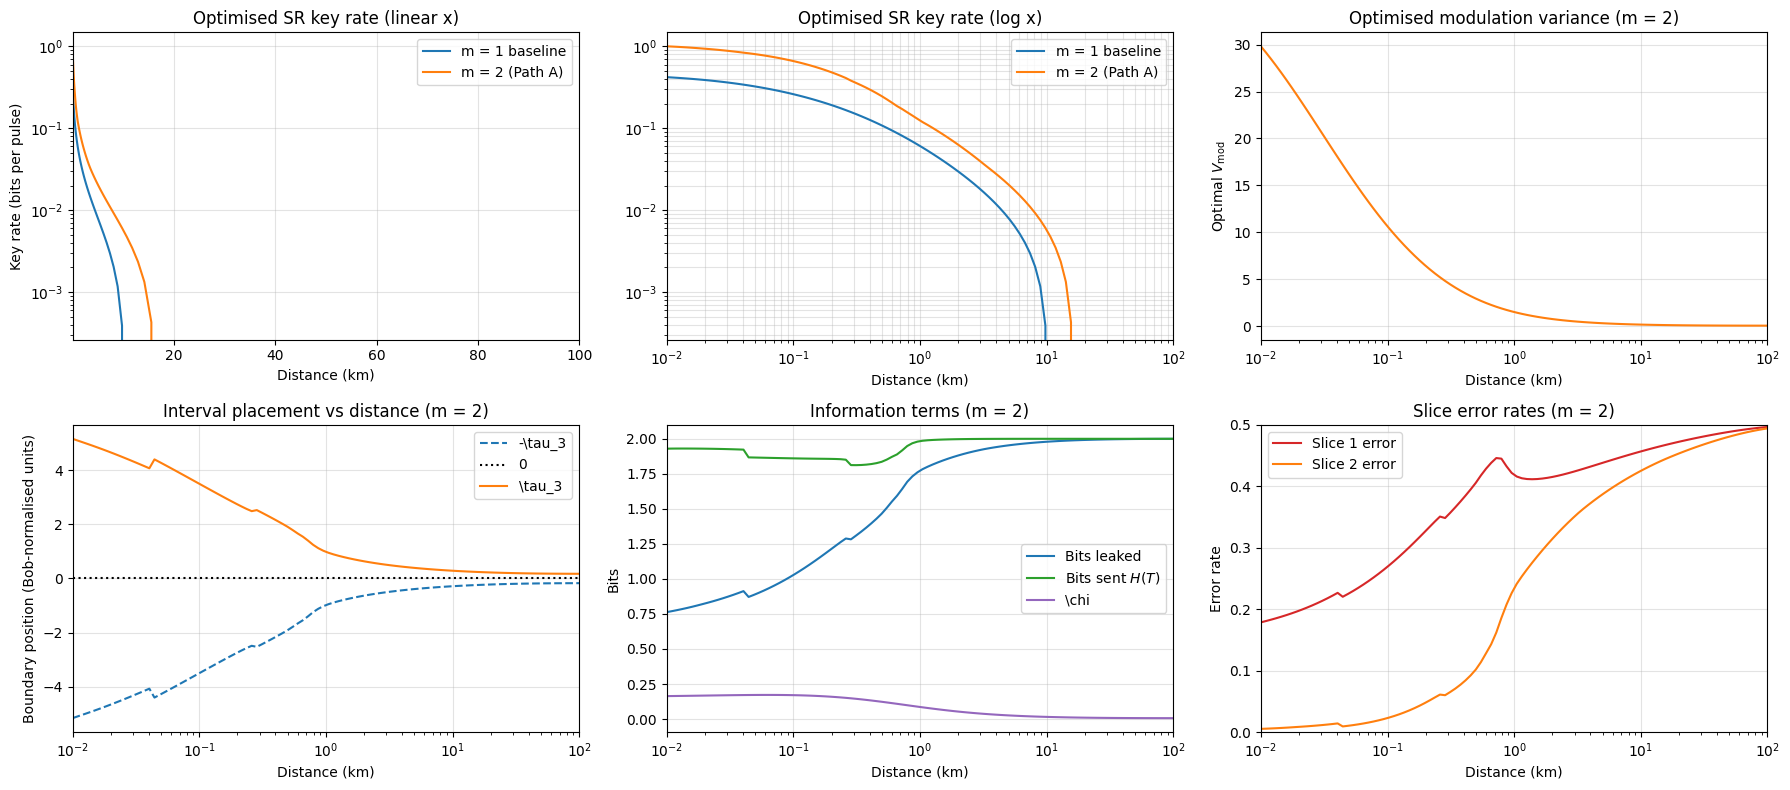

In [11]:
## Path A SR (m = 2) summary plots (matching 2x3 layout)
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
(ax_key_lin, ax_key_log, ax_vmod), (ax_tau, ax_bits, ax_errors) = axes

# Key rate vs distance (linear x for first panel)
ax_key_lin.plot(distances_km, optimal_key_rates, label='m = 1 baseline')
ax_key_lin.plot(pathA_distances, pathA_K_hard, label='m = 2 (Path A)')
ax_key_lin.set_xlabel('Distance (km)')
ax_key_lin.set_ylabel('Key rate (bits per pulse)')
ax_key_lin.set_title('Optimised SR key rate (linear x)')
ax_key_lin.set_yscale('log')
ax_key_lin.set_xlim(1e-2, 1e2)
ax_key_lin.grid(True, alpha=0.35)
ax_key_lin.legend()

# Key rate vs distance (log x)
ax_key_log.plot(distances_km, optimal_key_rates, label='m = 1 baseline')
ax_key_log.plot(pathA_distances, pathA_K_hard, label='m = 2 (Path A)')
ax_key_log.set_xlabel('Distance (km)')
ax_key_log.set_title('Optimised SR key rate (log x)')
ax_key_log.set_yscale('log')
ax_key_log.set_xscale('log')
ax_key_log.set_xlim(1e-2, 1e2)
ax_key_log.grid(True, which='both', alpha=0.35)
ax_key_log.legend()

# Modulation variance evolution (log x)
ax_vmod.plot(pathA_distances, pathA_V_mod_opt, color='tab:orange')
ax_vmod.set_xlabel('Distance (km)')
ax_vmod.set_ylabel(r'Optimal $V_{\mathrm{mod}}$')
ax_vmod.set_title('Optimised modulation variance (m = 2)')
ax_vmod.set_xscale('log')
ax_vmod.set_xlim(1e-2, 1e2)
ax_vmod.grid(True, alpha=0.35)

# Decision boundary placement (Bob-normalised units)
ax_tau.plot(pathA_distances, -pathA_tau_opt, linestyle='--', label='-\\tau_3')
ax_tau.plot(pathA_distances, np.zeros_like(pathA_tau_opt), linestyle=':', color='black', label='0')
ax_tau.plot(pathA_distances, pathA_tau_opt, label='\\tau_3')
ax_tau.set_xlabel('Distance (km)')
ax_tau.set_ylabel('Boundary position (Bob-normalised units)')
ax_tau.set_title('Interval placement vs distance (m = 2)')
ax_tau.set_xscale('log')
ax_tau.set_xlim(1e-2, 1e2)
ax_tau.grid(True, alpha=0.35)
ax_tau.legend()

# Information terms (bits)
ax_bits.plot(pathA_distances, pathA_bits_leaked, color='tab:blue', label='Bits leaked')
ax_bits.plot(pathA_distances, pathA_bits_sent, color='tab:green', label='Bits sent $H(T)$')
ax_bits.plot(pathA_distances, pathA_holevo, color='tab:purple', label='\\chi')
ax_bits.set_xlabel('Distance (km)')
ax_bits.set_ylabel('Bits')
ax_bits.set_title('Information terms (m = 2)')
ax_bits.set_xscale('log')
ax_bits.set_xlim(1e-2, 1e2)
ax_bits.grid(True, alpha=0.35)
ax_bits.legend()

# Slice error rates
ax_errors.plot(pathA_distances, pathA_eff_errors[:, 0], color='tab:red', label='Slice 1 error')
ax_errors.plot(pathA_distances, pathA_eff_errors[:, 1], color='tab:orange', label='Slice 2 error')
ax_errors.set_xlabel('Distance (km)')
ax_errors.set_ylabel('Error rate')
ax_errors.set_title('Slice error rates (m = 2)')
ax_errors.set_xscale('log')
ax_errors.set_xlim(1e-2, 1e2)
ax_errors.set_ylim(0.0, 0.5)
ax_errors.grid(True, alpha=0.35)
ax_errors.legend()

fig.tight_layout()